## Imports

In [1]:
!pip install -q datasets transformers evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import random
import torch
from torch import nn
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer, TrainingArguments, PreTrainedModel, PretrainedConfig
from transformers import EarlyStoppingCallback
import evaluate


In [3]:
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from datasets import Dataset
from torch.utils.data import DataLoader
rng = np.random.default_rng(42)

In [4]:
# @title
import wandb

wandb.init(
    project="timestomping-detector-nano-deltas",
    name="obvious_and_subtle_detection_deltas"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zeroranger to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Generate Data

### run 2

In [ ]:
# @title
def generate_benign(n=4000):
    rows = []
    for _ in range(n):
        base = rng.integers(1_577_836_800_000_000_000, 1_725_984_000_000_000_000)  # 2020–2025 in ns
        created = base
        modified = created + rng.integers(10_000_000_000, 3_600_000_000_000)
        accessed = modified + rng.integers(5_000_000_000, 3_600_000_000_000)
        entropy = rng.uniform(3.5, 7.5)
        rows.append([created, modified, accessed, modified - created, accessed - modified, entropy, 0])
    return rows

def generate_timestomp(n=4000, subtle_ratio=0.5):
    rows = []
    for _ in range(n):
        base = rng.integers(1_577_836_800_000_000_000, 1_725_984_000_000_000_000)
        created = base
        if rng.random() < subtle_ratio:
            modified = created - rng.integers(1_000_000_000, 30_000_000_000)
            accessed = modified + rng.integers(0, 10_000_000_000)
        else:
            modified = created - rng.integers(3_600_000_000_000, 86_400_000_000_000)
            accessed = modified - rng.integers(10_000_000_000, 600_000_000_000)
        entropy = rng.uniform(3.0, 6.5)
        rows.append([created, modified, accessed, modified - created, accessed - modified, entropy, 1])
    return rows

In [ ]:
# @title
benign = generate_benign()
timestomp = generate_timestomp()
data = benign + timestomp
random.shuffle(data)

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def to_records(X, y):
    return [{"input_ids": row, "label": int(lbl)} for row, lbl in zip(X, y)]

train_ds = Dataset.from_list(to_records(X_train, y_train)).rename_column("label", "labels")
test_ds  = Dataset.from_list(to_records(X_test, y_test)).rename_column("label", "labels")

In [5]:
# This script combines data generation (from data_generator.py)
# and preprocessing (from ml_preprocessing.py) into one runnable unit
# suitable for a Jupyter Notebook cell.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datasets import Dataset

# Initialize the random number generator
rng = np.random.default_rng()

# --- CONSTANTS ---
# Time range for timestamps (2020 to 2025 in 100-nanosecond intervals used by NTFS)
TIME_START = 15778368000000000  # Jan 1, 2020
TIME_END = 17259840000000000    # Sep 10, 2025

# Standard random noise (in 100-ns units) for ~90% of benign data (10ms)
MAX_STANDARD_NOISE = 10000000

# Extreme random jitter (in 100-ns units) for ~10% of benign data (up to 100 seconds)
# This jitter overlaps with the subtle stomp minimum (5 seconds) to force the model to learn
# the boundary and reduce the 1.0 F1 score.
MAX_EXTREME_JITTER = 1000000000 # 100 seconds

# --- HELPER FUNCTION FOR BENIGN TIME SEQUENCES ---
def generate_base_macb_sequence():
    """Generates a base sequence of C, M, A, B times that follow a logical progression (C < M < A, B=M)."""
    # 1. Create time (C)
    created = rng.integers(TIME_START, TIME_END)

    # 2. Entry Modified time (B) - Typically equals M time unless explicitly modified
    modified = created + rng.integers(1000000000, 3600000000000) # 100s to 100 hours after creation
    entry_modified = modified

    # 3. Access time (A) - Typically after modification
    accessed = modified + rng.integers(1000000000, 3600000000000) # 100s to 100 hours after modification

    # Ensure C < M < A and B = M
    return created, modified, accessed, entry_modified

# --- DATA GENERATION FUNCTIONS (Focusing on External Deltas: FN - SI) ---

def generate_benign_metadata(n=12000):
    """
    Generates Benign (Clean) metadata, introducing realistic system noise and
    extreme jitter to prevent perfect class separation.

    Returns: [FN_C, FN_M, FN_A, FN_B, Delta_C, Delta_M, Delta_A, Delta_B, Label]
    """
    rows = []
    for _ in range(n):
        # Generate base times for the $FN attribute (The ground truth timeline)
        fn_c, fn_m, fn_a, fn_b = generate_base_macb_sequence()

        # Decide on the noise floor: 10% chance of high jitter
        if rng.random() < 0.10:
            max_noise = MAX_EXTREME_JITTER # Up to 100 seconds (overlaps with subtle stomp)
        else:
            max_noise = MAX_STANDARD_NOISE # Up to 10 milliseconds (standard system noise)

        # Introduce small, random, positive OR negative noise to $SI relative to $FN
        noise_c = rng.integers(-max_noise, max_noise)
        noise_m = rng.integers(-max_noise, max_noise)
        noise_a = rng.integers(-max_noise, max_noise)
        noise_b = rng.integers(-max_noise, max_noise)

        si_c, si_m, si_a, si_b = fn_c + noise_c, fn_m + noise_m, fn_a + noise_a, fn_b + noise_b

        # Calculate the four external deltas (Time_FN - Time_SI)
        delta_c = fn_c - si_c
        delta_m = fn_m - si_m
        delta_a = fn_a - si_a
        delta_b = fn_b - si_b

        # Label = 0 (Benign/Clean)
        # INCLUDE ALL 8 VALUES (4 FN + 4 Delta)
        rows.append([fn_c, fn_m, fn_a, fn_b, delta_c, delta_m, delta_a, delta_b, 0])
    return rows

def generate_timestomp_metadata(n=12000, subtle_ratio=0.75):
    """
    Generates Stomped metadata where the $SI attribute is manipulated,
    creating significant, non-zero external deltas.

    Returns: [FN_C, FN_M, FN_A, FN_B, Delta_C, Delta_M, Delta_A, Delta_B, Label]
    """
    rows = []
    for _ in range(n):
        # 1. Generate base times for the $FN attribute (the true, untouched timeline)
        fn_c, fn_m, fn_a, fn_b = generate_base_macb_sequence()

        # 2. Simulate Time-Stomping on the $SI attribute:

        # Decide if the manipulation is subtle (short window) or obvious (long window)
        if rng.random() < subtle_ratio:
            # Subtle stomp: Move SI times back by 5 seconds to 5 hours
            stomp_offset = rng.integers(50000000, 180000000000)
        else:
            # Obvious stomp: Move SI times back significantly (e.g., 1 day to 1 year)
            stomp_offset = rng.integers(864000000000, 3153600000000000)  # 1 day to 1 year

        # $SI times are stomped to a new, false timeline, but maintain relative order
        si_c = fn_c - stomp_offset
        si_m = fn_m - stomp_offset
        si_a = fn_a - stomp_offset
        si_b = fn_b - stomp_offset

        # Calculate the four external deltas (Time_FN - Time_SI)
        delta_c = fn_c - si_c
        delta_m = fn_m - si_m
        delta_a = fn_a - si_a
        delta_b = fn_b - si_b

        # Label = 1 (Stomped)
        # INCLUDE ALL 8 VALUES (4 FN + 4 Delta)
        rows.append([fn_c, fn_m, fn_a, fn_b, delta_c, delta_m, delta_a, delta_b, 1])
    return rows

# --- 1. DATA GENERATION AND COMBINATION ---

print("--- Starting Data Generation ---")

# Generate a balanced dataset (4000 benign + 4000 stomped = 8000 total samples)
benign_data = generate_benign_metadata(n=4000)
stomped_data = generate_timestomp_metadata(n=4000)

# Combine into a single list
all_data = benign_data + stomped_data

# Define the 8 feature columns + 1 label column
new_columns = [
    'FN_Creation', 'FN_Modification', 'FN_Access', 'FN_EntryChange',
    'Delta_Creation', 'Delta_Modification', 'Delta_Access', 'Delta_EntryChange',
    'Label'
]

# Create DataFrame for easier manipulation, splitting, and shuffling
df = pd.DataFrame(all_data, columns=new_columns)
df = df.sample(frac=1).reset_index(drop=True) # Shuffle the combined data

print(f"Total samples generated: {len(df)}")
print("Sample of raw data (FN Timestamps and Deltas in 100-nanosecond units):")
print(df.head())

# --- 2. FEATURE ENGINEERING FOR NANOSECOND SENSITIVITY ---

# Features that will be Log-transformed and scaled (the 4 Delta features)
delta_cols = ['Delta_Creation', 'Delta_Modification', 'Delta_Access', 'Delta_EntryChange']

# Apply Log Transformation to Raw Deltas (Magnitude Compression)
for col in delta_cols:
    # Use np.log1p (log(1+x)) on the absolute value of the delta
    # CRITICAL: Using .abs() handles negative deltas caused by benign noise.
    df[f'{col}_Log'] = np.log1p(df[col].abs())

# Define the final feature set for the model (ONLY the 4 Log-transformed features)
X_cols = [col for col in df.columns if col.startswith('Delta_') and col.endswith('_Log')]
X = df[X_cols].values
y = df['Label'].values

print(f"\nEngineered feature count: {len(X_cols)}")
print(f"Feature shape: {X.shape}")
print(f"Engineered Features used for training: {X_cols}")


# --- 3. TRAIN/TEST SPLIT ---

# Split into 80% training and 20% testing sets, ensuring balanced labels (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\nTrain samples: {len(X_train)} | Test samples: {len(X_test)}")

# --- 4. FEATURE SCALING (Standardization on Engineered Features) ---

# Scaling is still crucial for the Log-Transformed features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Engineered features scaled using StandardScaler.")

# --- 5. HUGGING FACE DATASET CONVERSION ---

def to_records(X, y):
    """Converts NumPy arrays back to a list of dicts required by Dataset.from_list."""
    # input_ids now contains 4 scaled Log-transformed Delta features
    return [{"input_ids": row.tolist(), "label": int(lbl)} for row, lbl in zip(X, y)]

# Convert data to the Hugging Face Dataset format
train_ds = Dataset.from_list(to_records(X_train_scaled, y_train)).rename_column("label", "labels")
test_ds  = Dataset.from_list(to_records(X_test_scaled, y_test)).rename_column("label", "labels")

print("\n--- Hugging Face Datasets successfully created ---")
print("Training Dataset:")
print(train_ds)
print("\nTest Dataset:")
print(test_ds)

# Optional: Print a sample record
print("\nSample Training Record (Scaled):")
print(train_ds[0])

--- Starting Data Generation ---
Total samples generated: 8000
Sample of raw data (FN Timestamps and Deltas in 100-nanosecond units):
         FN_Creation    FN_Modification          FN_Access     FN_EntryChange  \
0  16451467548073892  16453755786471738  16453924094178745  16453755786471738   
1  16519107772309550  16521012593497464  16524228106422140  16521012593497464   
2  16767661066927581  16768536423340470  16770855410986242  16768536423340470   
3  16658692872089545  16661067007488207  16663110958752996  16661067007488207   
4  16672299716350696  16675708638645250  16676670909912840  16675708638645250   

     Delta_Creation  Delta_Modification      Delta_Access  Delta_EntryChange  \
0          -4580417            -9502733          -1011635            8985299   
1      100092527916        100092527916      100092527916       100092527916   
2           -601577            -4362615          -9287588           -1159648   
3           4533895            -8529714          -8788187  

## Model creation

In [6]:
import torch.nn as nn

class TabularMLP(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            # ⬆️ Increased width from 64 → 128
            # Rationale: more neurons in the first layer give the model capacity to learn richer
            # interactions between features (especially useful with nanosecond deltas + entropy).
            nn.Linear(input_dim, 128),

            # ⬆️ Added BatchNorm
            # Rationale: normalizes activations, stabilizes training, reduces sensitivity to scale.
            nn.BatchNorm1d(128),

            nn.ReLU(),

            # ⬆️ Increased dropout from 0.2 → 0.3
            # Rationale: stronger regularization to prevent overfitting with the wider layer.
            nn.Dropout(0.25),

            # ⬆️ Second hidden layer widened from 32 → 64
            # Rationale: smoother dimensionality reduction, avoids bottleneck too early.
            nn.Linear(128, 64),

            # ⬆️ Added BatchNorm here too
            # Rationale: keeps activations stable across deeper layers.
            nn.BatchNorm1d(64),

            nn.ReLU(),

            # ⬆️ Dropout kept at 0.2
            # Rationale: lighter regularization here since the layer is narrower.
            nn.Dropout(0.15),

            # ⬆️ Retained a 32-unit layer
            # Rationale: acts as a compact representation before output, similar to your original.
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            # ⬆️ Output layer unchanged
            # Rationale: still maps to 2 classes (benign vs. timestomp/wiped).
            nn.Linear(32, num_classes)
        )
    def forward(self, input_ids, labels=None):
        logits = self.net(input_ids)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


In [7]:
# ✅ Metrics setup
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision_score(labels, preds, average="macro"),
        "recall": recall_score(labels, preds, average="macro"),
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
args = TrainingArguments(
  output_dir="./timestomp_detector_nano_deltas",  # Where checkpoints/logs are saved
  eval_strategy="epoch",   # Evaluate after each epoch
  save_strategy="epoch",   # Save model after each epoch

  learning_rate=8e-4,       # 🔹 increased learning rate
  lr_scheduler_type="cosine",   # 🔹 added scheduler
  per_device_train_batch_size=64,
  per_device_eval_batch_size=128,
  num_train_epochs=200,
  weight_decay=0.02,
  logging_steps=50,
  warmup_ratio=0.1,
  gradient_accumulation_steps=1,
  remove_unused_columns=False,
  load_best_model_at_end=True,       # restore best checkpoint
  metric_for_best_model="f1",        # prioritize balanced detection
  greater_is_better=True,
  dataloader_pin_memory=False
)

input_dim = len(train_ds[0]["input_ids"])  # number of features
hf_model = TabularMLP(input_dim=input_dim, num_classes=2)

In [9]:
trainer = Trainer(
    model=hf_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [10]:
metrics = trainer.evaluate()
print(metrics.keys())

dict_keys(['eval_loss', 'eval_model_preparation_time', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second'])


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Training

In [11]:
trainer.train()
metrics = trainer.evaluate()
metrics

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,Precision,Recall,F1
1,0.744500,0.671359,0.004600,0.700625,0.812744,0.700625,0.671152
2,0.431500,0.341781,0.004600,0.996875,0.996882,0.996875,0.996875
3,0.213800,0.166259,0.004600,0.987500,0.987805,0.987500,0.987498
4,0.102400,0.077603,0.004600,0.995625,0.995663,0.995625,0.995625
5,0.057200,0.037432,0.004600,0.998750,0.998753,0.998750,0.998750
6,0.033600,0.021943,0.004600,0.998125,0.998132,0.998125,0.998125
7,0.026000,0.013471,0.004600,0.998125,0.998132,0.998125,0.998125
8,0.024800,0.010340,0.004600,0.999375,0.999376,0.999375,0.999375
9,0.014000,0.008367,0.004600,0.999375,0.999376,0.999375,0.999375
10,0.019500,0.007178,0.004600,0.998750,0.998753,0.998750,0.998750


{'eval_loss': 0.01033975463360548,
 'eval_model_preparation_time': 0.0046,
 'eval_accuracy': 0.999375,
 'eval_precision': 0.9993757802746567,
 'eval_recall': 0.999375,
 'eval_f1': 0.9993749997558592,
 'eval_runtime': 0.2793,
 'eval_samples_per_second': 5727.972,
 'eval_steps_per_second': 46.54,
 'epoch': 13.0}

## AI Detection

In [13]:
benign_samples = test_ds.filter(lambda x: x["labels"] == 0).select(range(100))
timestomp_samples = test_ds.filter(lambda x: x["labels"] == 1).select(range(100))

print(benign_samples[:3])
print(timestomp_samples[:3])

Filter:   0%|          | 0/1600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1600 [00:00<?, ? examples/s]

{'input_ids': [[-0.8004136353999197, -0.8494066973689811, -0.8149924102695963, -0.8440783101484544], [-0.9227687550442766, -0.9146026261194736, -0.8674105815398979, -0.795472118687612], [-0.9564348970001955, -1.0629096506958091, -0.8962391512213567, -0.8858205766279298]], 'labels': [0, 0, 0]}
{'input_ids': [[2.136100430503994, 2.1363954881748426, 2.1324464162403363, 2.1334969052599644], [0.6187633232725611, 0.6181951038333621, 0.618877214667705, 0.6184295103275183], [0.6272338959625307, 0.6266704957895826, 0.6273267529292539, 0.6268874122913041]], 'labels': [1, 1, 1]}


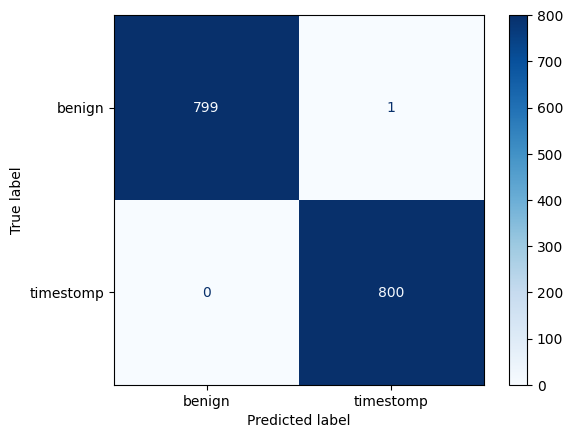

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

preds = trainer.predict(test_ds)
y_true = preds.label_ids
y_pred = (y_scores >= 0.5223615).astype(float)

#y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign","timestomp"])
disp.plot(cmap="Blues")
plt.show()

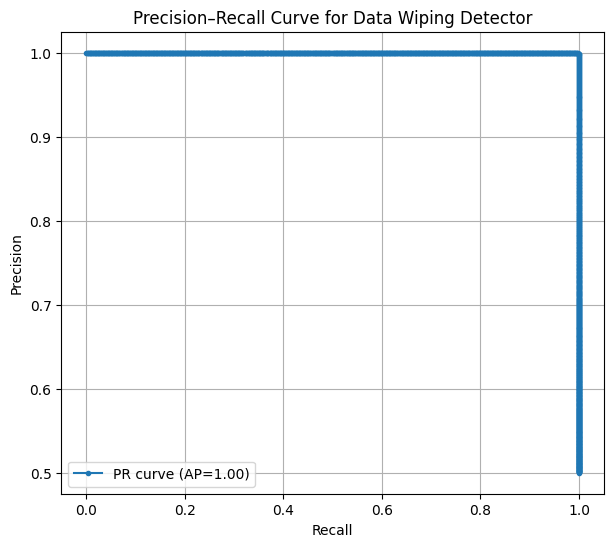

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


# Run evaluation on your test set
predictions = trainer.predict(test_ds)

# predictions.predictions are the raw logits
logits = predictions.predictions
y_true = predictions.label_ids

import torch
import numpy as np

# Convert logits → probabilities for class 1 (wiped)
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_scores = probs[:, 1]   # probability of "wiped"


precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, marker='.', label=f'PR curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve for Data Wiping Detector')
plt.legend()
plt.grid(True)
plt.show()

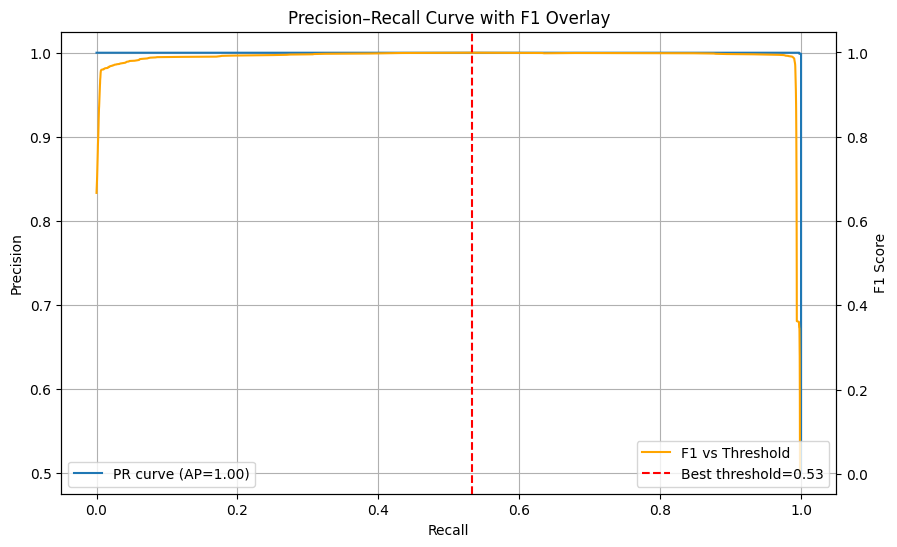

Best threshold: 0.53299683
Best F1: 0.9993753903810119


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

# y_true: ground truth labels (0=benign, 1=wiped)
# y_scores: predicted probabilities for class 1 (wiped)

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

# Compute F1 at each threshold
f1_scores = []
for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    f1_scores.append(f1_score(y_true, y_pred))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Plot PR curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve with F1 Overlay')
plt.legend()
plt.grid(True)

# Plot F1 vs threshold on a secondary axis
plt.twinx()
plt.plot(thresholds, f1_scores, color='orange', label='F1 vs Threshold')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold={best_threshold:.2f}')
plt.ylabel('F1 Score')
plt.legend(loc='lower right')

plt.show()

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

## Rule based detection

In [ ]:
import torch

# Save just the model weights
torch.save(hf_model.state_dict(), "timestomp_model_nano_based.pt")
torch.save(hf_model, "timestomp_model_nano_full_based.pt")


# Save the scaler too (using joblib or pickle)
import joblib
joblib.dump(scaler, "scaler_timestomp_nano_based.pkl")


['scaler_timestomp_nano_based.pkl']

In [ ]:
from google.colab import files
files.download("timestomp_model_nano_based.pt")
files.download("timestomp_model_nano_cutoff_full_based.pt")
files.download("scaler_timestomp_nano_based.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sum(p.numel() for p in hf_model.parameters())

11682

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp timestomp_model.pt /content/drive/MyDrive/
# !cp scaler.pkl /content/drive/MyDrive/

Mounted at /content/drive
